# Actividad 4 - Normalización por Sujeto (Grupos BioVid)
**Desarrollado por Cristóbal Piña**

**Objetivo:** Aplicar la técnica de **Resta de Línea de Base** para eliminar la variabilidad biológica del BioVid y recalcular la matriz de correlación lineal.

## 1. Importación de Librerías y Conexión a Drive

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# Se monta el Google Drive para acceder a la carpeta compartida GPI para despues usar el dataset
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Carga del Dataset Original
Se extrae el archivo desde el acceso directo de la carpeta compartida GPI alojado en Drive.


In [ ]:
# Cargargamos el dataset utilizando la ruta del acceso directo creado previamente
ruta_archivo = '/content/drive/Shareddrives/GPI/dataset_features_biovid.csv'

df = pd.read_csv(ruta_archivo)

## 3. Normalización y Resta de Línea de Base

**Propósito de aislar sujetos específicos:**
Cada individuo posee ritmos biológicos basales únicos. Al aislar a los sujetos, podemos calcular el promedio de su estado de reposo absoluto (BL1) de forma independiente. Al restar este valor de sus señales en bruto ($X_{neto} = X_{bruto} - U_{baseline}$), eliminamos el sesgo fisiológico inherente a cada cuerpo. Esto transforma los datos absolutos en cambios netos relativos, logrando que todas las personas partan de un nivel "cero" común, lo que hace que sus reacciones frente a los estímulos sean directamente comparables.

In [ ]:
# Definidas las variables fisiológicas a normalizar (Del ejemplo que mando el gabo)
metricas = ['ecg_bpm', 'gsr_peaks_count', 'gsr_max_amplitude', 'emg_trapezius_auc', 'emg_corrugator_auc', 'emg_zygomaticus_auc']

# Esta operación calcula el promedio basal (BL1) por sujeto
df_baselines = df[df['class_name'] == 'BL1'].groupby('subject_name')[metricas].mean().reset_index()

# Alineamos la señal en bruto con promedio basal
df_unificado = df.merge(df_baselines, on='subject_name', suffixes=('', '_baseline'))

# Se crea el dataframe neto y aplica resta de línea de base
df_neto = df_unificado[['subject_name', 'class_id', 'class_name']].copy()

for col in metricas:
    df_neto[f'{col}_neto'] = df_unificado[col] - df_unificado[f'{col}_baseline']

# Se Exporta el dataset normalizado
df_neto.to_csv('dataset_features_biovid_normalizado.csv', index=False)
print("Normalización completada. Archivo dataset_features_biovid_normalizado.csv exportado.")

Normalización completada. Archivo dataset_features_biovid_normalizado.csv exportado.


## 4. Visualización: Nuevo Mapa de Calor de Correlaciones
Se genera la matriz de correlación utilizando exclusivamente las métricas normalizadas (valores netos) para observar la respuesta limpia ante el estímulo (`class_id`).

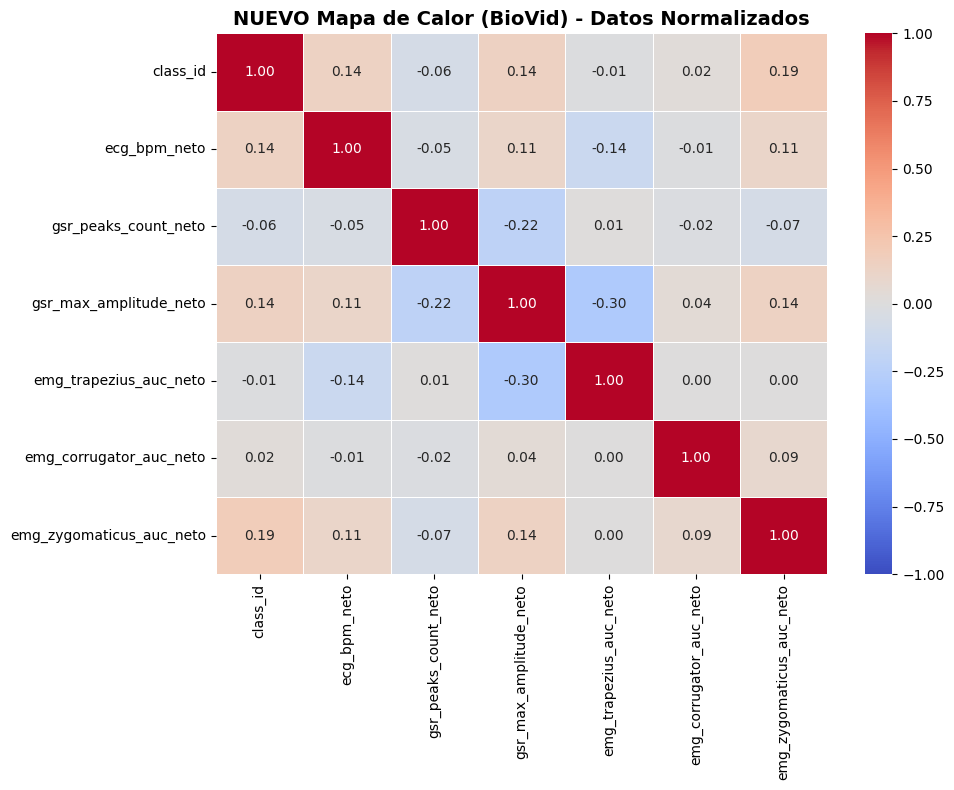

In [ ]:
plt.figure(figsize=(10, 8))

# Seleccionar únicamente las columnas numéricas para el cálculo de la matriz de correlación
df_numerico = df_neto.select_dtypes(include=[np.number])

# Generar el mapa de calor con los límites de correlación estándar (-1 a 1)
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('NUEVO Mapa de Calor (BioVid) - Datos Normalizados', fontsize=14, fontweight='bold')
plt.tight_layout()

# Exportar el gráfico como archivo de imagen para el entregable
plt.savefig('nuevo_mapa_calor_biovid.png', dpi=150)
plt.show()

## 5. Validación Matemática de la Normalización

**Justificación Técnica:**
El objetivo final de este proceso es auditar y comprobar matemáticamente que la técnica de normalización se aplicó de forma correcta sobre el dataset. Para esto, se aísla exclusivamente el estado de reposo absoluto (`BL1`) y se calcula su promedio general.

Siguiendo la lógica de la resta de línea de base, si al valor en reposo se le resta su propio promedio basal, el resultado teórico obligatorio es cero. Los valores obtenidos en la salida (expresados en notación científica como `e-16` o `e-17`) representan el cero absoluto computacional en Python, lo que certifica de manera estadística que el sesgo biológico inicial de todos los sujetos fue eliminado con éxito.

In [ ]:
# Comprobar el promedio de las variables netas exclusivas de la clase BL1
prueba_cero = df_neto[df_neto['class_name'] == 'BL1'].mean(numeric_only=True)
print(prueba_cero)

class_id                    0.000000e+00
ecg_bpm_neto               -7.353291e-16
gsr_peaks_count_neto       -1.883764e-15
gsr_max_amplitude_neto      3.356488e-17
emg_trapezius_auc_neto     -2.935168e-09
emg_corrugator_auc_neto    -4.316960e-16
emg_zygomaticus_auc_neto   -4.544169e-17
dtype: float64
